# **PHASE 1: BUSINESS UNDERSTANDING**

This is the first phase of the Cross-Industry Process for Data Mining , famously known as CRISP-DM. This phase clearly outlines the objective of the project that guides the making of the project. 

**Questions, decision and hypothesis:**

Do countries that spend more on education relative to their income have higher primary, secondary and tertiary enrolment and lower primary dropout? The decision this informs is whether education budgets, measured as a share of GDP, are a useful lever for improving access to school. My hypothesis is that higher spending goes with higher enrolment, but that its link to lower dropout is weaker. I expect this because enrolment responds directly to the schools a budget can build and staff, while dropout depends on conditions a budget share does not capture, such as household poverty and distance to school. I will test this with country-level data, and I will not be able to claim that spending causes any difference.

# **PHASE 2: DATA UNDERSTANDING**

My project uses six public datasets, from two publishers, that describe education spending, school enrolment and income in countries around the world. Four come from Our World in Data (OWID), originally compiled from the World Bank and UNESCO. One is an extract from the World Bank’s World Development Indicators (WDI). One is the World Bank’s income classification history. My focus is on whether countries that spend more on education relative to their income have higher enrolment and lower dropout. The main explanatory variable is education spending as a share of GDP. The outcomes are enrolment at primary, secondary and tertiary level, and the dropout measures. During the pre-processing stage I removed non-country rows, reshaped the wide WDI table, turned `..` into missing values, and joined the sources on country code and year. I also checked how spending relates to enrolment, and built extra columns from the original ones (feature engineering).

**Observations in each dataset**

Education spending (OWID): 5,205 observations and 4 columns in the raw file. After removing regions and aggregates, 5,164 country-year rows remain, covering 206 countries from 1970 to 2025.
Primary school enrolment, gross (OWID): 8,570 raw observations. After cleaning, 7,778 country-year rows remain, covering 221 countries from 1970 to 2025.
Tertiary school enrolment, gross (OWID): 6,112 raw observations. After cleaning, 5,367 country-year rows remain, covering 206 countries from 1970 to 2025.
Children not in school (OWID): 5,005 raw observations. After cleaning, 4,693 country-year rows remain, covering 217 countries from 1970 to 2025.
World Development Indicators extract (WDI): 2,915 data rows (one per country and indicator) and 46 year columns, for 11 indicators. After reshaping from wide to long, it has 8,928 country-year rows, covering 213 countries from 1980 to 2025.
World Bank income classification: 8,090 country-year rows after cleaning, covering 223 economies from 1987 to 2025. Each is classified as Low, Lower middle, Upper middle or High income.

**Input and outcome variables**

a) Education spending (% of GDP) b) Gross primary enrolment c) Gross tertiary enrolment d) Children out of school (% of primary-age children) e) GDP per capita (PPP) f) Gross secondary enrolment g) Net primary enrolment h) Net secondary enrolment i) Pre-primary enrolment j) Persistence to the last grade of primary k) Government spending per primary student (% of GDP per capita) l) Income group

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl

# Load the datasets

In [2]:
import os
CLEAN = 'C:/Users/kevin/capstone_kevina/data/cleaned'
os.makedirs(CLEAN, exist_ok=True)

not_in_school_raw = pd.read_csv('C:/Users/kevin/capstone_kevina/data/raw/children-not-in-school.csv')
spending_raw = pd.read_csv('C:/Users/kevin/capstone_kevina/data/raw/education-spending.csv')
primary_enroll_raw = pd.read_csv('C:/Users/kevin/capstone_kevina/data/raw/primary-school-enrolment.csv')
sec_enroll_raw = pd.read_csv('C:/Users/kevin/capstone_kevina/data/raw/secondary-school-enrolment.csv')
tertiary_raw = pd.read_csv('C:/Users/kevin/capstone_kevina/data/raw/tertiary-school-enrolment.csv')
income_group = pd.read_excel('C:/Users/kevin/capstone_kevina/data/raw/OGHIST_2026_07_15.xlsx', sheet_name='Country Analytical History', header=None)
wdi_extract_raw = pd.read_excel('C:/Users/kevin/capstone_kevina/data/raw/P_Data_Extract_From_World_Development_Indicators (1).xlsx')

# Describing and cleaning of each dataset

# 01. World Bank WDI extract (11 indicators)
**Source:** World Development Indicators, last updated 07/13/2026 (DataBank), file `P_Data_Extract_From_World_Development_Indicators_1.xlsx`.
**Layout:** wide. One row per country and indicator, one column per year (`1980 [YR1980]`...), `..` for missing values, and 5 junk rows at the bottom.
**Goal:** one tidy table with one row per country and year and one column per indicator.

In [3]:
wdi = wdi_extract_raw.copy()
print(wdi_extract_raw.shape)
print('Series in raw file:',wdi_extract_raw['Series Code'].nunique())

(2920, 50)
Series in raw file: 11


In [4]:
wdi_extract_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 50 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   2917 non-null   str   
 1   Country Code   2915 non-null   str   
 2   Series Name    2915 non-null   str   
 3   Series Code    2915 non-null   str   
 4   1980 [YR1980]  2915 non-null   object
 5   1981 [YR1981]  2915 non-null   object
 6   1982 [YR1982]  2915 non-null   object
 7   1983 [YR1983]  2915 non-null   object
 8   1984 [YR1984]  2915 non-null   object
 9   1985 [YR1985]  2915 non-null   object
 10  1986 [YR1986]  2915 non-null   object
 11  1987 [YR1987]  2915 non-null   object
 12  1988 [YR1988]  2915 non-null   object
 13  1989 [YR1989]  2915 non-null   object
 14  1990 [YR1990]  2915 non-null   object
 15  1991 [YR1991]  2915 non-null   object
 16  1992 [YR1992]  2915 non-null   object
 17  1993 [YR1993]  2915 non-null   object
 18  1994 [YR1994]  2915 non-null   object
 

In [5]:
wdi_extract_raw.describe()

,Country Name,Country Code,Series Name,Series Code,1980 [YR1980],1981 [YR1981],1982 [YR1982],1983 [YR1983],1984 [YR1984],1985 [YR1985],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
count,2917,2915,2915,2915,2915,2915,2915,2915,2915,2915,...,2915,2915,2915,2915,2915,2915,2915,2915,2915,2915
unique,267,265,11,11,849,914,887,895,911,892,...,1926,1847,1706,1478,1481,1348,1233,1183,866,283
top,Argentina,ARG,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
freq,11,11,265,265,2050,1989,2013,2005,1991,2011,...,946,1027,1172,1396,1403,1542,1648,1701,2044,2633


In [6]:
wdi

,Country Name,Country Code,Series Name,Series Code,1980 [YR1980],1981 [YR1981],1982 [YR1982],1983 [YR1983],1984 [YR1984],1985 [YR1985],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Argentina,ARG,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,2.60715,..,1.59787,1.6175,2.56972,1.36186,...,5.54549,5.45433,4.87774,4.77166,5.2769,4.65393,4.79263,5.00324,..,..
1,Argentina,ARG,"Government expenditure per student, primary (%...",SE.XPD.PRIM.PC.ZS,..,..,..,..,..,..,...,15.2222,14.97726,..,..,..,..,..,..,..,..
2,Argentina,ARG,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,..,..,..,..,..,..,...,27802.10572,28334.904185,27367.115094,26629.552942,23877.09314,26300.274261,27825.027349,27230.39685,26771.965765,27846.59846
3,Argentina,ARG,"School enrollment, tertiary (% gross)",SE.TER.ENRR,21.565029,22.963421,23.695709,24.7787,28.72756,35.666592,...,86.674383,89.329735,91.084651,95.192824,99.369735,107.219558,107.103901,107.822574,..,..
4,Argentina,ARG,"School enrollment, secondary (% gross)",SE.SEC.ENRR,56.184021,57.603149,59.57502,60.405998,65.958099,70.644707,...,109.598328,110.3778,109.671242,110.460152,112.376732,115.735779,114.148117,105.574584,..,..
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2918,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
wdi.isna().sum()

Country Name     3
Country Code     5
Series Name      5
Series Code      5
1980 [YR1980]    5
1981 [YR1981]    5
1982 [YR1982]    5
1983 [YR1983]    5
1984 [YR1984]    5
1985 [YR1985]    5
1986 [YR1986]    5
1987 [YR1987]    5
1988 [YR1988]    5
1989 [YR1989]    5
1990 [YR1990]    5
1991 [YR1991]    5
1992 [YR1992]    5
1993 [YR1993]    5
1994 [YR1994]    5
1995 [YR1995]    5
1996 [YR1996]    5
1997 [YR1997]    5
1998 [YR1998]    5
1999 [YR1999]    5
2000 [YR2000]    5
2001 [YR2001]    5
2002 [YR2002]    5
2003 [YR2003]    5
2004 [YR2004]    5
2005 [YR2005]    5
2006 [YR2006]    5
2007 [YR2007]    5
2008 [YR2008]    5
2009 [YR2009]    5
2010 [YR2010]    5
2011 [YR2011]    5
2012 [YR2012]    5
2013 [YR2013]    5
2014 [YR2014]    5
2015 [YR2015]    5
2016 [YR2016]    5
2017 [YR2017]    5
2018 [YR2018]    5
2019 [YR2019]    5
2020 [YR2020]    5
2021 [YR2021]    5
2022 [YR2022]    5
2023 [YR2023]    5
2024 [YR2024]    5
2025 [YR2025]    5
dtype: int64

## Step A: Remove the non-data raws

The dataset ends with 3 blank rows aand 2 footer lines ('Data from database...' and 'Last Updated...'). The footer lines have text in the `Country Name`, so that column is not a safe filter. `Series Code` and `Country Code` are filled on every real row and empty on every junk row as we can see on the `wdi.isna().sum()` code output, so a row missing either on is not data


In [8]:
wdi = wdi.dropna(subset=['Series Code', 'Country Code'], how='any')
print(wdi.shape)
wdi.tail(3).iloc[:, :4]

(2915, 50)


,Country Name,Country Code,Series Name,Series Code
2912,Zimbabwe,ZWE,"School enrollment, preprimary (% gross)",SE.PRE.ENRR
2913,Zimbabwe,ZWE,"Persistence to last grade of primary, total (%...",SE.PRM.PRSL.ZS
2914,Zimbabwe,ZWE,Children out of school (% of primary school age),SE.PRM.UNER.ZS


In [9]:
wdi.tail(10)

,Country Name,Country Code,Series Name,Series Code,1980 [YR1980],1981 [YR1981],1982 [YR1982],1983 [YR1983],1984 [YR1984],1985 [YR1985],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
2905,Zimbabwe,ZWE,"Government expenditure per student, primary (%...",SE.XPD.PRIM.PC.ZS,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
2906,Zimbabwe,ZWE,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,..,..,..,..,..,..,...,5070.424132,5234.406538,5415.49322,4993.865469,4527.739492,4827.109602,5036.783177,5218.045266,5211.897556,5529.2331
2907,Zimbabwe,ZWE,"School enrollment, tertiary (% gross)",SE.TER.ENRR,1.48163,1.86025,2.1947,1.42452,1.62802,1.8955,...,..,..,..,..,..,..,..,..,7.74913,..
2908,Zimbabwe,ZWE,"School enrollment, secondary (% gross)",SE.SEC.ENRR,8.94398,15.19347,22.15682,29.26726,37.012249,41.204788,...,..,..,..,..,..,..,..,..,..,..
2909,Zimbabwe,ZWE,"School enrollment, secondary (% net)",SE.SEC.NENR,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
2910,Zimbabwe,ZWE,"School enrollment, primary (% gross)",SE.PRM.ENRR,92.906372,115.131851,124.158432,128.466248,129.080139,129.189804,...,95.734095,94.334173,93.755202,93.427097,93.612586,92.784691,93.165966,93.238379,93.077211,..
2911,Zimbabwe,ZWE,"School enrollment, primary (% net)",SE.PRM.NENR,..,..,97.63049,..,99.00948,..,...,..,..,..,..,..,..,..,..,..,..
2912,Zimbabwe,ZWE,"School enrollment, preprimary (% gross)",SE.PRE.ENRR,..,..,..,..,..,..,...,67.283859,70.518204,69.689369,71.712189,72.525597,74.315247,..,..,..,..
2913,Zimbabwe,ZWE,"Persistence to last grade of primary, total (%...",SE.PRM.PRSL.ZS,..,..,..,73.539558,..,..,...,79.806412,83.190536,85.336761,87.570152,..,..,..,..,..,..
2914,Zimbabwe,ZWE,Children out of school (% of primary school age),SE.PRM.UNER.ZS,..,..,0.14345,..,..,..,...,17.685101,19.44088,18.764561,18.38135,16.914289,9.426102,8.173392,9.137232,10.524499,..


## Step B: reshape from wide to long

The year columns are named like `1980 [YR1980]`. `melt` truns the 46 year columns into rows

In [10]:
id_cols = ['Country Name', 'Country Code', 'Series Name', 'Series Code']
year_cols = [c for c in wdi.columns if '[YR' in c]
print(len(year_cols), 'year columns')

long = wdi.melt(id_vars=id_cols, value_vars=year_cols, var_name='year_raw', value_name='value_raw')
print(long.shape)
long.head(3)

46 year columns
(134090, 6)


,Country Name,Country Code,Series Name,Series Code,year_raw,value_raw
0,Argentina,ARG,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,1980 [YR1980],2.60715
1,Argentina,ARG,"Government expenditure per student, primary (%...",SE.XPD.PRIM.PC.ZS,1980 [YR1980],..
2,Argentina,ARG,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,1980 [YR1980],..


## Step C: turn the year labels into integers
`'1980 [YR1980]'` becomes `1980`. Keeping `year` as an integer matches the `Year` columnin the OWID tables, so the join keys line up.

In [11]:
long['year'] = long['year_raw'].str[:4].astype(int)
print(long['year'].dtype, long['year'].min(), long['year'].max())

int64 1980 2025


In [12]:
long.head(5)

,Country Name,Country Code,Series Name,Series Code,year_raw,value_raw,year
0,Argentina,ARG,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,1980 [YR1980],2.60715,1980
1,Argentina,ARG,"Government expenditure per student, primary (%...",SE.XPD.PRIM.PC.ZS,1980 [YR1980],..,1980
2,Argentina,ARG,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,1980 [YR1980],..,1980
3,Argentina,ARG,"School enrollment, tertiary (% gross)",SE.TER.ENRR,1980 [YR1980],21.565029,1980
4,Argentina,ARG,"School enrollment, secondary (% gross)",SE.SEC.ENRR,1980 [YR1980],56.184021,1980


## Step D: turn `..` into real missing values

Every year column mixes numbers and the text `..`, so pandas stores them as text. `pd.to_numeric(errors='coerce)` converts numbers and turn anything unparseable (here only `..`) into `NaN`.

In [13]:
print(long['value_raw'].astype(str).value_counts().head(3))

long['value'] = pd.to_numeric(long['value_raw'], errors='coerce')
print('non-null values:', long['value'].notna().sum())
print('missing values:', long['value'].isna().sum())

value_raw
..     70113
0         20
100       20
Name: count, dtype: int64
non-null values: 63977
missing values: 70113


## Step E: drop the empty rows(decision)

After Step D, most rows have no values. Each source is cleaned on its own and joined afterwards,

In [14]:
before = len(long)
long = long.dropna(subset=["value"])
print(f"rows before: {before:,}   after: {len(long):,}   dropped: {before - len(long):,}")

rows before: 134,090   after: 63,977   dropped: 70,113


In [15]:
long.isna().sum()

Country Name    0
Country Code    0
Series Name     0
Series Code     0
year_raw        0
value_raw       0
year            0
value           0
dtype: int64

## Step F: remove aggregates
The extract includes regions and income groups (World, Sub-Saharan Africa, High income, ...). They are not countries and would double-count. Their World Bank codes are listed below.

In [16]:
aggregate_codes = {
    "AFE","AFW","ARB","CEB","CSS","EAP","EAR","EAS","ECA","ECS","EMU","EUU","FCS","HIC","HPC",
    "IBD","IBT","IDA","IDB","IDX","INX","LAC","LCN","LDC","LIC","LMC","LMY","LTE","MEA","MIC",
    "MNA","NAC","OED","OSS","PRE","PSS","PST","SAS","SSA","SSF","SST","TEA","TEC","TLA","TMN",
    "TSA","TSS","UMC","WLD",
}
print("entities before:", long["Country Code"].nunique())
print("aggregates found:", sorted(set(long["Country Code"]) & aggregate_codes)[:8], "...")

long = long[~long["Country Code"].isin(aggregate_codes)]
print("entities after :", long["Country Code"].nunique())   # expect 213 (the file has 217 country codes, 4 report no values at all)
print("rows after     :", f"{len(long):,}")

entities before: 260
aggregates found: ['AFE', 'AFW', 'ARB', 'CEB', 'CSS', 'EAP', 'EAR', 'EAS'] ...
entities after : 213
rows after     : 49,115


## Step G: long to wide (one row per country and year)
`pivot_table` turns the 11 series into 11 columns. Short, readable column names make the later steps easier.

In [17]:
names = {
    "SE.XPD.TOTL.GD.ZS": "spend_pct_gdp",
    "SE.XPD.PRIM.PC.ZS": "spend_per_primary_student",
    "NY.GDP.PCAP.PP.KD": "gdp_pc_ppp",
    "SE.PRE.ENRR":       "enr_preprimary",
    "SE.PRM.ENRR":       "enr_primary_gross",
    "SE.PRM.NENR":       "enr_primary_net",
    "SE.SEC.ENRR":       "enr_secondary_gross",
    "SE.SEC.NENR":       "enr_secondary_net",
    "SE.TER.ENRR":       "enr_tertiary_gross",
    "SE.PRM.PRSL.ZS":    "persistence_last_grade",
    "SE.PRM.UNER.ZS":    "out_of_school_pct",
}

wdi_clean = (long.pivot_table(index=["Country Code", "Country Name", "year"], columns="Series Code", values="value")
                 .rename(columns=names).reset_index())
wdi_clean.columns.name = None
wdi_clean = wdi_clean.rename(columns={"Country Code": "code", "Country Name": "country"})
print(wdi_clean.shape)
wdi_clean

(8928, 14)


,code,country,year,gdp_pc_ppp,enr_preprimary,enr_primary_gross,enr_primary_net,persistence_last_grade,out_of_school_pct,enr_secondary_gross,enr_secondary_net,enr_tertiary_gross,spend_per_primary_student,spend_pct_gdp
0,ABW,Aruba,1990,33146.670548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,1991,34079.230463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,1992,34458.142298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,1993,34627.743475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,1994,35580.533978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8923,ZWE,Zimbabwe,2021,4827.109602,74.315247,92.784691,NaN,NaN,9.426102,NaN,NaN,NaN,NaN,NaN
8924,ZWE,Zimbabwe,2022,5036.783177,NaN,93.165966,NaN,NaN,8.173392,NaN,NaN,NaN,NaN,NaN
8925,ZWE,Zimbabwe,2023,5218.045266,NaN,93.238379,NaN,NaN,9.137232,NaN,NaN,NaN,NaN,0.384771
8926,ZWE,Zimbabwe,2024,5211.897556,NaN,93.077211,NaN,NaN,10.524499,NaN,NaN,7.74913,NaN,NaN


## Step F: Checks before saving

In [18]:
print("country-year rows :", len(wdi_clean))
print("countries          :", wdi_clean["code"].nunique())
print("duplicate keys     :", wdi_clean.duplicated(["code", "year"]).sum())   # must be 0
print("years              :", wdi_clean["year"].min(), "to", wdi_clean["year"].max())
print()
print("non-null values per indicator:")
print(wdi_clean.drop(columns=["code", "country", "year"]).notna().sum())

country-year rows : 8928
countries          : 213
duplicate keys     : 0
years              : 1980 to 2025

non-null values per indicator:
gdp_pc_ppp                   6977
enr_preprimary               5289
enr_primary_gross            6411
enr_primary_net              3836
persistence_last_grade       3565
out_of_school_pct            4268
enr_secondary_gross          5358
enr_secondary_net            2517
enr_tertiary_gross           4671
spend_per_primary_student    1602
spend_pct_gdp                4621
dtype: int64


In [19]:
wdi_clean.info()
wdi_clean.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   code                       8928 non-null   str    
 1   country                    8928 non-null   str    
 2   year                       8928 non-null   int64  
 3   gdp_pc_ppp                 6977 non-null   float64
 4   enr_preprimary             5289 non-null   float64
 5   enr_primary_gross          6411 non-null   float64
 6   enr_primary_net            3836 non-null   float64
 7   persistence_last_grade     3565 non-null   float64
 8   out_of_school_pct          4268 non-null   float64
 9   enr_secondary_gross        5358 non-null   float64
 10  enr_secondary_net          2517 non-null   float64
 11  enr_tertiary_gross         4671 non-null   float64
 12  spend_per_primary_student  1602 non-null   float64
 13  spend_pct_gdp              4621 non-null   float64
dtypes: 

,count,mean,std,min,25%,50%,75%,max
year,8928.0,2003.316196,13.000308,1980.000000,1992.000000,2004.000000,2015.000000,2025.000000
gdp_pc_ppp,6977.0,22109.045184,24340.024821,510.822823,4502.492840,12728.081459,32535.662514,174569.523171
enr_preprimary,5289.0,53.468169,34.877807,0.000000,22.607161,53.764679,83.578430,245.847183
enr_primary_gross,6411.0,98.826957,19.199313,13.781030,94.565699,101.120262,108.021044,198.885193
enr_primary_net,3836.0,86.243640,15.977668,14.308450,84.329693,92.288090,96.428515,100.000000
persistence_last_grade,3565.0,82.739459,18.828343,6.923750,72.018562,91.022728,97.501221,100.000000
out_of_school_pct,4268.0,11.629127,15.657875,0.000000,1.482787,5.323145,13.714647,85.606308
enr_secondary_gross,5358.0,71.898158,33.147924,2.473480,44.657447,80.104509,97.388464,164.079819
enr_secondary_net,2517.0,68.381108,25.559545,0.215030,50.724850,77.771860,88.553840,99.911640
enr_tertiary_gross,4671.0,31.487986,28.371536,0.000000,6.839055,22.132940,52.325066,166.389557


## Step G: Outlier check on spending (decision)

In [20]:
wdi_clean["spend_suspect"] = (wdi_clean["spend_pct_gdp"] < 0.1) | (wdi_clean["spend_pct_gdp"] > 25)
print("suspect spending values:", wdi_clean["spend_suspect"].sum())
wdi_clean[wdi_clean["spend_suspect"]][["code", "country", "year", "spend_pct_gdp"]]

suspect spending values: 7


,code,country,year,spend_pct_gdp
7276,SOM,"Somalia, Fed. Rep.",2018,0.000004
7277,SOM,"Somalia, Fed. Rep.",2019,0.000006
7278,SOM,"Somalia, Fed. Rep.",2020,0.000006
7279,SOM,"Somalia, Fed. Rep.",2021,0.000007
7280,SOM,"Somalia, Fed. Rep.",2022,0.000007
7281,SOM,"Somalia, Fed. Rep.",2023,0.000008
8131,TUR,Turkiye,1998,0.000000


In [21]:
wdi_clean.columns.to_list()

['code',
 'country',
 'year',
 'gdp_pc_ppp',
 'enr_preprimary',
 'enr_primary_gross',
 'enr_primary_net',
 'persistence_last_grade',
 'out_of_school_pct',
 'enr_secondary_gross',
 'enr_secondary_net',
 'enr_tertiary_gross',
 'spend_per_primary_student',
 'spend_pct_gdp',
 'spend_suspect']

## Step H: Distribution (Phase 2)
Plot the two variables the question is about: spending and GDP per capita.

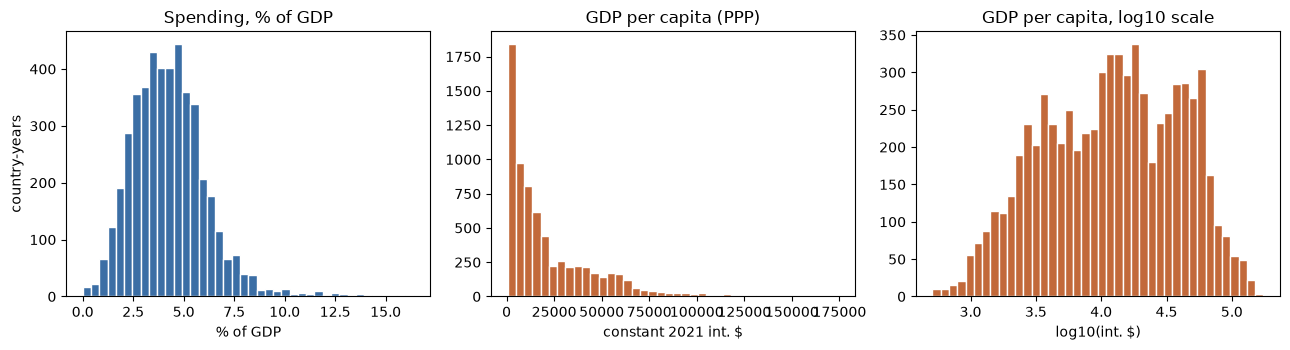

,spend_pct_gdp,gdp_pc_ppp,persistence_last_grade,enr_primary_gross
mean,4.30,22109.05,82.74,98.83
median,4.16,12728.08,91.02,101.12
std,1.92,24340.02,18.83,19.20
skew,1.24,1.86,-1.28,-1.11


In [22]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].hist(wdi_clean["spend_pct_gdp"].dropna(), bins=40, color="#3b6ea5", edgecolor="white")
ax[0].set(title="Spending, % of GDP", xlabel="% of GDP", ylabel="country-years")
ax[1].hist(wdi_clean["gdp_pc_ppp"].dropna(), bins=40, color="#c2693a", edgecolor="white")
ax[1].set(title="GDP per capita (PPP)", xlabel="constant 2021 int. $")
ax[2].hist(wdi_clean["gdp_pc_ppp"].dropna().pipe(lambda s: s[s > 0]).pipe(__import__("numpy").log10), bins=40, color="#c2693a", edgecolor="white")
ax[2].set(title="GDP per capita, log10 scale", xlabel="log10(int. $)")
plt.tight_layout(); plt.show()
wdi_clean[["spend_pct_gdp", "gdp_pc_ppp", "persistence_last_grade", "enr_primary_gross"]].agg(["mean", "median", "std", "skew"]).round(2)

**Shape (draft, check against your plot):** spending is mildly right-skewed (skewness about 1.2), with a median near 4.2% of GDP. GDP per capita is strongly right-skewed (mean about 22,000 against a median near 12,700), a few very rich economies pull the tail out, and the log scale looks close to symmetric.

## Step I: Save

In [23]:
wdi_clean.to_csv(f"{CLEAN}/wdi_clean.csv", index=False)
print("saved", wdi_clean.shape)
wdi_clean.head()

saved (8928, 15)


,code,country,year,gdp_pc_ppp,enr_preprimary,enr_primary_gross,enr_primary_net,persistence_last_grade,out_of_school_pct,enr_secondary_gross,enr_secondary_net,enr_tertiary_gross,spend_per_primary_student,spend_pct_gdp,spend_suspect
0,ABW,Aruba,1990,33146.670548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,ABW,Aruba,1991,34079.230463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,ABW,Aruba,1992,34458.142298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,ABW,Aruba,1993,34627.743475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,ABW,Aruba,1994,35580.533978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


# 02. Primary school enrollment (gross %)

**Source:** Our World in Data, `primary-school-enrolment.csv` (originally UNESCO Institute for Statistics).
**Layout:** already long: one row per country and year (`Entity, Code, Year, value`), so no reshaping is needed.
**This notebook:** look at the raw table, remove non-countries, restrict the years, check keys, plot the distribution, save a clean CSV.

## 1. Raw table (Shape, data types, missing values)

In [24]:
primary_enroll_raw.shape

(8570, 4)

In [25]:
primary_enroll_raw.describe()

,Year,Primary education
count,8570.000000,8570.000000
mean,1999.639790,97.039568
std,15.649426,21.654255
min,1970.000000,3.118000
25%,1986.000000,92.070463
50%,2002.000000,100.754160
75%,2013.000000,107.829003
max,2025.000000,214.642620


In [26]:
primary_enroll_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8570 entries, 0 to 8569
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Entity             8570 non-null   str    
 1   Code               8270 non-null   str    
 2   Year               8570 non-null   int64  
 3   Primary education  8570 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 381.5 KB


In [27]:
null = primary_enroll_raw.isna().sum()
null

Entity                 0
Code                 300
Year                   0
Primary education      0
dtype: int64

## 2. The `Code` column
OWID leaves `Code` blank for regional aggregates and uses prefixes soch as `OWID_` and `WB_` for groups. A real country has a three-letter code (`KEN`, `ARG`)

In [28]:
codes = primary_enroll_raw['Code']
print('blank codes:', null)
print('codes that are not three letters:', (~codes.dropna().str.fullmatch(r'[A-Z]{3}')))
non_country = primary_enroll_raw[codes.isna() | ~codes.fillna('').str.fullmatch(r'[A-Z]{3}')]
non_country[['Entity', 'Code']].drop_duplicates().head(12)

blank codes: Entity                 0
Code                 300
Year                   0
Primary education      0
dtype: int64
codes that are not three letters: 0       False
1       False
2       False
3       False
4       False
        ...  
8565    False
8566    False
8567    False
8568    False
8569    False
Name: Code, Length: 8270, dtype: bool


,Entity,Code
1447,Central and Southern Asia (SDG),NaN
2099,East Asia and Pacific (WB),WB_EAP
2175,Eastern and South-Eastern Asia (SDG),NaN
2530,Europe and Central Asia (WB),WB_ECA
2556,Europe and Northern America (SDG),NaN
2582,European Union (27),OWID_EU27
3259,High-income countries,OWID_HIC
4073,Latin America and Caribbean (WB),WB_LAC
4105,Latin America and the Caribbean (SDG),NaN
4345,Low-income countries,OWID_LIC


## 3. Clean
1. Rename the columns to short names.
2. Keep only rows with a three-letter code.
3. Keep 1970 to 2025 the range of the other sources.
4. Assert that each `code` and `year` pair appears once. A duplicate key would multiply rows in the join.

In [29]:
prim_clean = primary_enroll_raw.copy()
prim_clean.columns = ['entity', 'code', 'year', 'enr_primary_gross']
n0 = len(prim_clean)

prim_clean = prim_clean[prim_clean['code'].str.fullmatch(r'[A-Z]{3}', na=False)]
n1 = len(prim_clean)
prim_clean = prim_clean[prim_clean['year'].between(1970, 2025)]
n2 = len(prim_clean)

assert not prim_clean.duplicated(['code', 'year']).any()
assert prim_clean['enr_primary_gross'].notna().all()
prim_clean = prim_clean.reset_index(drop=True)

print(f'raw rows: {n0:,}')
print(f'after removing non-countries: {n1:,} (removed {n0 - n1:,})')
print(f'after year filter 1970-2025: {n2:,} (removed {n1 - n2:,})')
print('countries:', prim_clean['code'].nunique(), '| years:', prim_clean['year'].min(), 'to', prim_clean['year'].max())

raw rows: 8,570
after removing non-countries: 7,778 (removed 792)
after year filter 1970-2025: 7,778 (removed 0)
countries: 221 | years: 1970 to 2025


## 4. Distribution

C:\Users\kevin\AppData\Local\Temp\ipykernel_6048\195153129.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(prim_clean["enr_primary_gross"], vert=True)


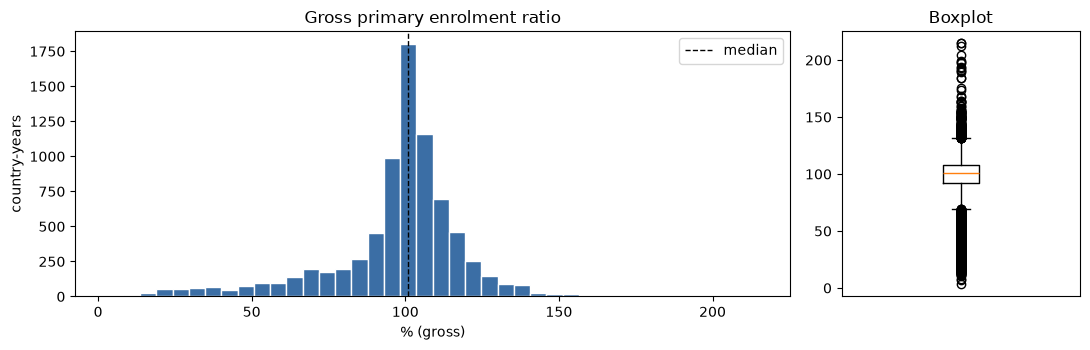

skewness: -1.04 | mean: 97.2 | median: 100.8


In [30]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [3, 1]})
ax[0].hist(prim_clean["enr_primary_gross"], bins=40, color="#3b6ea5", edgecolor="white")
ax[0].axvline(prim_clean["enr_primary_gross"].median(), color="black", ls="--", lw=1, label="median")
ax[0].set(title="Gross primary enrolment ratio", xlabel="% (gross)", ylabel="country-years")
ax[0].legend()
ax[1].boxplot(prim_clean["enr_primary_gross"], vert=True)
ax[1].set(title="Boxplot", xticks=[])
plt.tight_layout(); plt.show()
print("skewness:", round(prim_clean["enr_primary_gross"].skew(), 2), "| mean:", round(prim_clean["enr_primary_gross"].mean(), 1),
      "| median:", round(prim_clean["enr_primary_gross"].median(), 1))

**Shape (draft, check against your plot):** left-skewed, with a tall peak around 100% and a tail down to very low values (skewness about -1). More than half the country-years (4,165 of 7,778) are above 100%. This is normal, not an error: gross enrolment counts everyone enrolled, including over-age and under-age pupils, divided by the school-age population, so it can pass 100%. Values go up to about 215%. 

## 5. Save

In [31]:
prim_clean.to_csv(f"{CLEAN}/owid_enr_primary_gross.csv", index=False)
print("saved", prim_clean.shape)
prim_clean.head()


saved (7778, 4)


,entity,code,year,enr_primary_gross
0,Afghanistan,AFG,1970,31.65142
1,Afghanistan,AFG,1971,32.53972
2,Afghanistan,AFG,1972,32.96287
3,Afghanistan,AFG,1973,33.42452
4,Afghanistan,AFG,1974,33.96281


# 03. Upper secondary school enrollment(gross %) 

## 1. Describe the raw table (shapes, types, missing values)

In [32]:
sec_enroll_raw.shape

(4491, 4)

In [33]:
sec_enroll_raw.describe()

,Year,Upper secondary education
count,4491.000000,4491.000000
mean,2010.850145,72.566307
std,7.975940,34.851447
min,1981.000000,1.267750
25%,2004.000000,45.048460
50%,2011.000000,76.321730
75%,2018.000000,96.864995
max,2025.000000,225.903660


In [34]:
sec_enroll_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4491 entries, 0 to 4490
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Entity                     4491 non-null   str    
 1   Code                       4300 non-null   str    
 2   Year                       4491 non-null   int64  
 3   Upper secondary education  4491 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 201.1 KB


## 2. The `Code` column
OWID leaves `Code` blank for regional aggregates and uses prefixes such as `OWID_` and `WB_` for groups. A real country has a three-letter code (`KEN`, `ARG`).

In [35]:
codes = sec_enroll_raw["Code"]
print("blank codes:", codes.isna().sum())
print("codes that are not three letters:", (~codes.dropna().str.fullmatch(r"[A-Z]{3}")).sum())
non_country = sec_enroll_raw[codes.isna() | ~codes.fillna("").str.fullmatch(r"[A-Z]{3}")]
non_country[["Entity", "Code"]].drop_duplicates().head(12)

blank codes: 191
codes that are not three letters: 337


,Entity,Code
759,Central and Southern Asia (SDG),NaN
1136,East Asia and Pacific (WB),WB_EAP
1183,Eastern and South-Eastern Asia (SDG),NaN
1376,Europe and Central Asia (WB),WB_ECA
1402,Europe and Northern America (SDG),NaN
1428,European Union (27),OWID_EU27
1713,High-income countries,OWID_HIC
2169,Latin America and Caribbean (WB),WB_LAC
2195,Latin America and the Caribbean (SDG),NaN
2345,Low-income countries,OWID_LIC


## 3. Clean
1. Rename the columns to short names.
2. Keep only rows with a three-letter code. (OWID codes Kosovo as `OWID_KOS`, so it is dropped too. The World Bank file uses another code for it, so it would not match anyway.)
3. Keep 1970 to 2025, the range of the other sources.
4. Assert that each `code` and `year` pair appears once. A duplicate key would multiply rows in the join.

In [36]:
sec_clean = sec_enroll_raw.copy()
sec_clean.columns = ["entity", "code", "year", "enr_upper_secondary"]
n0 = len(sec_clean)

sec_clean = sec_clean[sec_clean["code"].str.fullmatch(r"[A-Z]{3}", na=False)]
n1 = len(sec_clean)
sec_clean = sec_clean[sec_clean["year"].between(1970, 2025)]
n2 = len(sec_clean)

assert not sec_clean.duplicated(["code", "year"]).any()
assert sec_clean["enr_upper_secondary"].notna().all()
sec_clean = sec_clean.reset_index(drop=True)

print(f"raw rows: {n0:,}")
print(f"after removing non-countries: {n1:,}  (removed {n0 - n1:,})")
print(f"after year filter 1970-2025 : {n2:,}  (removed {n1 - n2:,})")
print("countries:", sec_clean["code"].nunique(), "| years:", sec_clean["year"].min(), "to", sec_clean["year"].max())

raw rows: 4,491
after removing non-countries: 3,963  (removed 528)
after year filter 1970-2025 : 3,963  (removed 0)
countries: 208 | years: 1981 to 2025


## 4. Distribution (Phase 2)

C:\Users\kevin\AppData\Local\Temp\ipykernel_6048\1577643233.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(sec_clean["enr_upper_secondary"], vert=True)


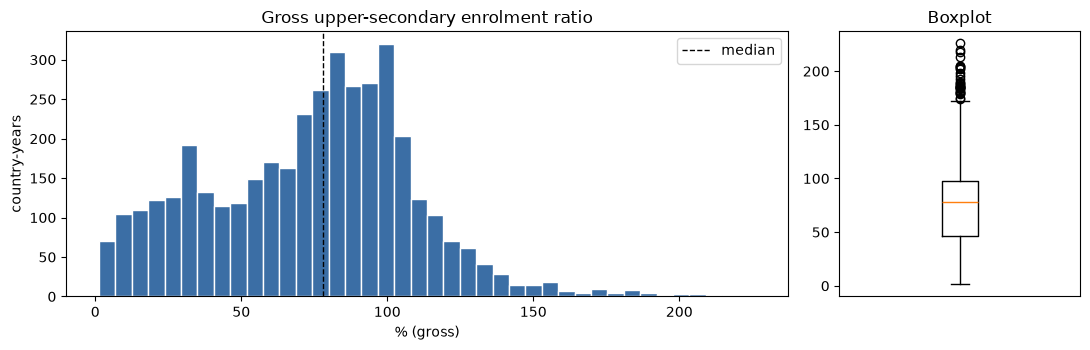

skewness: 0.13 | mean: 73.8 | median: 78.1


In [37]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [3, 1]})
ax[0].hist(sec_clean["enr_upper_secondary"], bins=40, color="#3b6ea5", edgecolor="white")
ax[0].axvline(sec_clean["enr_upper_secondary"].median(), color="black", ls="--", lw=1, label="median")
ax[0].set(title="Gross upper-secondary enrolment ratio", xlabel="% (gross)", ylabel="country-years")
ax[0].legend()
ax[1].boxplot(sec_clean["enr_upper_secondary"], vert=True)
ax[1].set(title="Boxplot", xticks=[])
plt.tight_layout(); plt.show()
print("skewness:", round(sec_clean["enr_upper_secondary"].skew(), 2), "| mean:", round(sec_clean["enr_upper_secondary"].mean(), 1),
      "| median:", round(sec_clean["enr_upper_secondary"].median(), 1))

**Shape (draft, check against your plot):** roughly symmetric (skewness near 0) but very spread out: the standard deviation is about 35 points and values run from about 1% to 226%. There is a broad plateau between about 45% and 98% rather than a single sharp peak. **Note:** this OWID file is *upper* secondary only. The WDI extract has total secondary enrolment (`enr_secondary_gross`), which has almost twice as many values.


## 5. Save

In [38]:
sec_clean.to_csv(f"{CLEAN}/owid_enr_upper_secondary.csv", index=False)
print("saved", sec_clean.shape)
sec_clean.head()

saved (3963, 4)


,entity,code,year,enr_upper_secondary
0,Afghanistan,AFG,2001,13.37796
1,Afghanistan,AFG,2003,8.59119
2,Afghanistan,AFG,2004,12.12437
3,Afghanistan,AFG,2005,12.79614
4,Afghanistan,AFG,2006,17.23782


# 04. Tertiary school enrollment (gross %)

## 1. Raw table (Shape, types, missing values)

In [39]:
tertiary_raw.shape

(6112, 4)

In [40]:
tertiary_raw.describe()

,Year,Tertiary education
count,6112.000000,6112.000000
mean,2001.021106,27.997809
std,15.495167,27.745029
min,1970.000000,0.000000
25%,1988.000000,4.852988
50%,2004.000000,17.591375
75%,2014.000000,46.726132
max,2025.000000,166.389560


In [41]:
tertiary_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 6112 entries, 0 to 6111
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Entity              6112 non-null   str    
 1   Code                5842 non-null   str    
 2   Year                6112 non-null   int64  
 3   Tertiary education  6112 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 273.0 KB


## 2. The `Code` column
OWID leaves `Code` blank for regional aggregates and uses prefixes such as `OWID_` and `WB_` for groups. A real country has a three-letter code (`KEN`, `ARG`).

In [42]:
codes = tertiary_raw["Code"]
print("blank codes:", codes.isna().sum())
print("codes that are not three letters:", (~codes.dropna().str.fullmatch(r"[A-Z]{3}")).sum())
non_country = tertiary_raw[codes.isna() | ~codes.fillna("").str.fullmatch(r"[A-Z]{3}")]
non_country[["Entity", "Code"]].drop_duplicates().head(12)

blank codes: 270
codes that are not three letters: 475


,Entity,Code
1027,Central and Southern Asia (SDG),NaN
1500,East Asia and Pacific (WB),WB_EAP
1559,Eastern and South-Eastern Asia (SDG),NaN
1822,Europe and Central Asia (WB),WB_ECA
1848,Europe and Northern America (SDG),NaN
1874,European Union (27),OWID_EU27
2212,High-income countries,OWID_HIC
2867,Latin America and Caribbean (WB),WB_LAC
2893,Latin America and the Caribbean (SDG),NaN
3096,Low-income countries,OWID_LIC


## 3. Clean
1. Rename the columns to short names.
2. Keep only rows with a three-letter code. (OWID codes Kosovo as `OWID_KOS`, so it is dropped too. The World Bank file uses another code for it, so it would not match anyway.)
3. Keep 1970 to 2025, the range of the other sources.
4. Assert that each `code` and `year` pair appears once. A duplicate key would multiply rows in the join.

In [43]:
ter_clean = tertiary_raw.copy()
ter_clean.columns = ["entity", "code", "year", "enr_tertiary_gross"]
n0 = len(ter_clean)

ter_clean = ter_clean[ter_clean["code"].str.fullmatch(r"[A-Z]{3}", na=False)]
n1 = len(ter_clean)
ter_clean = ter_clean[ter_clean["year"].between(1970, 2025)]
n2 = len(ter_clean)

assert not ter_clean.duplicated(["code", "year"]).any()
assert ter_clean["enr_tertiary_gross"].notna().all()
ter_clean = ter_clean.reset_index(drop=True)

print(f"raw rows: {n0:,}")
print(f"after removing non-countries: {n1:,}  (removed {n0 - n1:,})")
print(f"after year filter 1970-2025 : {n2:,}  (removed {n1 - n2:,})")
print("countries:", ter_clean["code"].nunique(), "| years:", ter_clean["year"].min(), "to", ter_clean["year"].max())

raw rows: 6,112
after removing non-countries: 5,367  (removed 745)
after year filter 1970-2025 : 5,367  (removed 0)
countries: 206 | years: 1970 to 2025


## 4. Distribution (Phase 2)

C:\Users\kevin\AppData\Local\Temp\ipykernel_6048\2188786922.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(ter_clean["enr_tertiary_gross"], vert=True)


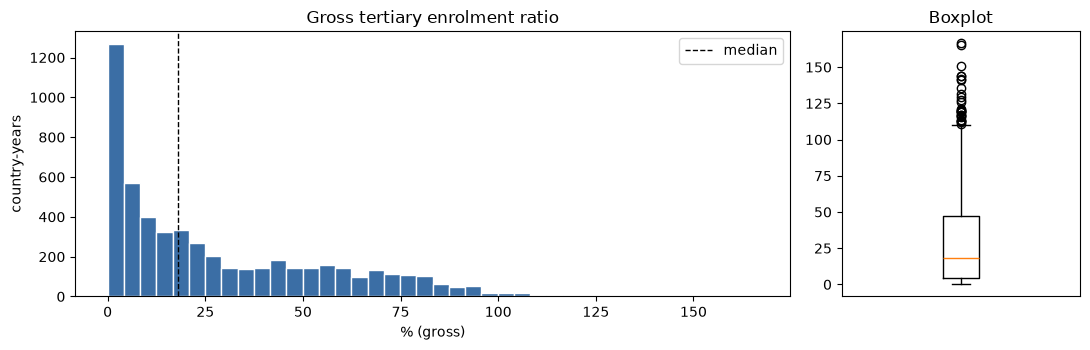

skewness: 1.02 | mean: 28.2 | median: 17.9


In [44]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [3, 1]})
ax[0].hist(ter_clean["enr_tertiary_gross"], bins=40, color="#3b6ea5", edgecolor="white")
ax[0].axvline(ter_clean["enr_tertiary_gross"].median(), color="black", ls="--", lw=1, label="median")
ax[0].set(title="Gross tertiary enrolment ratio", xlabel="% (gross)", ylabel="country-years")
ax[0].legend()
ax[1].boxplot(ter_clean["enr_tertiary_gross"], vert=True)
ax[1].set(title="Boxplot", xticks=[])
plt.tight_layout(); plt.show()
print("skewness:", round(ter_clean["enr_tertiary_gross"].skew(), 2), "| mean:", round(ter_clean["enr_tertiary_gross"].mean(), 1),
      "| median:", round(ter_clean["enr_tertiary_gross"].median(), 1))

**Shape (draft, check against your plot):** right-skewed (skewness about 1). Most country-years are below 20% (median about 18%), with a long tail towards 80% to 100% for richer countries and a few values above 100% (68 rows). The mean (28) is well above the median (18).

## 5. Save

In [45]:
ter_clean.to_csv(f"{CLEAN}/owid_enr_tertiary_gross.csv", index=False)
print("saved", ter_clean.shape)
ter_clean.head()

saved (5367, 4)


,entity,code,year,enr_tertiary_gross
0,Afghanistan,AFG,1970,0.76956
1,Afghanistan,AFG,1971,0.92827
2,Afghanistan,AFG,1972,0.95954
3,Afghanistan,AFG,1973,1.10444
4,Afghanistan,AFG,1974,1.03192


# 05. Children not in school (share of primary-school-age children)
**Source:** Our World in Data, `children-not-in-school.csv` (originally UNESCO Institute for Statistics).
**Layout:** already long: one row per country and year (`Entity, Code, Year, value`), so no reshaping is needed.
**This notebook:** look at the raw table, remove non-countries, restrict the years, check keys, plot the distribution, save a clean CSV.

## 1. Raw table (shape, types, missing values)

In [46]:
not_in_school_raw.shape

(5005, 4)

In [47]:
not_in_school_raw.describe()

,Year,Primary school age
count,5005.000000,5005.000000
mean,2005.336863,13.000556
std,14.046898,16.739970
min,1970.000000,0.000000
25%,1998.000000,1.794950
50%,2008.000000,6.242300
75%,2017.000000,16.700000
max,2025.000000,89.712580


In [48]:
not_in_school_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5005 entries, 0 to 5004
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Entity              5005 non-null   str    
 1   Code                4823 non-null   str    
 2   Year                5005 non-null   int64  
 3   Primary school age  5005 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 219.1 KB


## 2. The `Code` column
OWID leaves `Code` blank for regional aggregates and uses prefixes such as `OWID_` and `WB_` for groups. A real country has a three-letter code (`KEN`, `ARG`).

In [49]:
codes = tertiary_raw["Code"]
print("blank codes:", codes.isna().sum())
print("codes that are not three letters:", (~codes.dropna().str.fullmatch(r"[A-Z]{3}")).sum())
non_country = tertiary_raw[codes.isna() | ~codes.fillna("").str.fullmatch(r"[A-Z]{3}")]
non_country[["Entity", "Code"]].drop_duplicates().head(12)

blank codes: 270
codes that are not three letters: 475


,Entity,Code
1027,Central and Southern Asia (SDG),NaN
1500,East Asia and Pacific (WB),WB_EAP
1559,Eastern and South-Eastern Asia (SDG),NaN
1822,Europe and Central Asia (WB),WB_ECA
1848,Europe and Northern America (SDG),NaN
1874,European Union (27),OWID_EU27
2212,High-income countries,OWID_HIC
2867,Latin America and Caribbean (WB),WB_LAC
2893,Latin America and the Caribbean (SDG),NaN
3096,Low-income countries,OWID_LIC


## 3. Clean
1. Rename the columns to short names.
2. Keep only rows with a three-letter code. (OWID codes Kosovo as `OWID_KOS`, so it is dropped too. The World Bank file uses another code for it, so it would not match anyway.)
3. Keep 1970 to 2025, the range of the other sources.
4. Assert that each `code` and `year` pair appears once. A duplicate key would multiply rows in the join.

In [50]:
oos_clean = not_in_school_raw.copy()
oos_clean.columns = ["entity", "code", "year", "out_of_school_share"]
n0 = len(oos_clean)

oos_clean = oos_clean[oos_clean["code"].str.fullmatch(r"[A-Z]{3}", na=False)]
n1 = len(oos_clean)
oos_clean = oos_clean[oos_clean["year"].between(1970, 2025)]
n2 = len(oos_clean)

assert not oos_clean.duplicated(["code", "year"]).any()
assert oos_clean["out_of_school_share"].notna().all()
oos_clean = oos_clean.reset_index(drop=True)

print(f"raw rows: {n0:,}")
print(f"after removing non-countries: {n1:,}  (removed {n0 - n1:,})")
print(f"after year filter 1970-2025 : {n2:,}  (removed {n1 - n2:,})")
print("countries:", oos_clean["code"].nunique(), "| years:", oos_clean["year"].min(), "to", oos_clean["year"].max())

raw rows: 5,005
after removing non-countries: 4,693  (removed 312)
after year filter 1970-2025 : 4,693  (removed 0)
countries: 217 | years: 1970 to 2025


## 4. Distribution

C:\Users\kevin\AppData\Local\Temp\ipykernel_6048\1023258241.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(oos_clean["out_of_school_share"], vert=True)


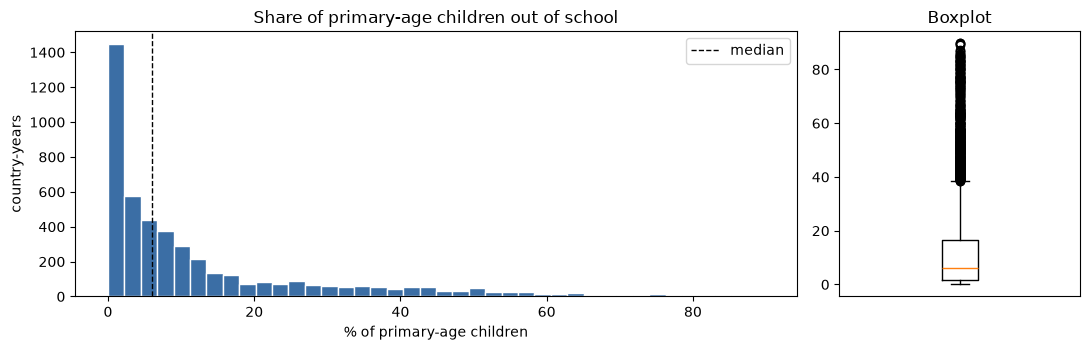

skewness: 1.94 | mean: 13.1 | median: 6.1


In [51]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [3, 1]})
ax[0].hist(oos_clean["out_of_school_share"], bins=40, color="#3b6ea5", edgecolor="white")
ax[0].axvline(oos_clean["out_of_school_share"].median(), color="black", ls="--", lw=1, label="median")
ax[0].set(title="Share of primary-age children out of school", xlabel="% of primary-age children", ylabel="country-years")
ax[0].legend()
ax[1].boxplot(oos_clean["out_of_school_share"], vert=True)
ax[1].set(title="Boxplot", xticks=[])
plt.tight_layout(); plt.show()
print("skewness:", round(oos_clean["out_of_school_share"].skew(), 2), "| mean:", round(oos_clean["out_of_school_share"].mean(), 1),
      "| median:", round(oos_clean["out_of_school_share"].median(), 1))

**Shape (draft, check against your plot):** strongly right-skewed (skewness about 1.9). Most country-years are below 6%, with the median near 6%, and a long tail up to about 90%. This is the best dropout stand-in for primary school, but it measures children *never in* school as well as those who left, so it is not a pure dropout rate.

## 5. Save

In [52]:
oos_clean.to_csv(f"{CLEAN}/owid_out_of_school_share.csv", index=False)
print("saved", oos_clean.shape)
oos_clean.head()

saved (4693, 4)


,entity,code,year,out_of_school_share
0,Afghanistan,AFG,1974,72.48552
1,Afghanistan,AFG,1993,68.77155
2,Albania,ALB,1999,3.06716
3,Albania,ALB,2000,3.14056
4,Albania,ALB,2001,3.11346


# 06. World Bank income groups
**Source:** World Bank country income classifications history, `OGHIST_2026_07_15.xlsx`, sheet `Country Analytical History`.
**Layout:** wide. Title rows, a fiscal-year row, a calendar-year row, one row per economy, a footnote at the bottom. Values are `L`, `LM`, `UM`, `H`.
**Goal:** one row per country and year with an income group, to join on `code` and `year`.

## 1. Raw sheet
The workbook has five sheets. The first (`Parameters`) is a 9-row table, not the one we need. Look at the right sheet with `header=None` before choosing a header.

In [53]:
print(income_group.shape)
income_group.iloc[3:9, :6]

(235, 41)


,0,1,2,3,4,5
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Bank's fiscal year:,FY89,FY90,FY91,FY92
5,NaN,Data for calendar year :,1987,1988,1989,1990
6,AFG,Afghanistan,L,L,L,L
7,ALB,Albania,..,..,..,LM
8,DZA,Algeria,UM,UM,LM,LM


Row 4 holds fiscal years (`FY89`...), row 5 holds the **calendar year of the GNI data** the classification was based on (`1987`...), and economies start on row 6.

**Which year do I join on?** The calendar year in row 5. It is the year the income figure describes, so it lines up with the year of the spending and enrolment data. The fiscal-year label is when the classification took effect, about a year later.

In [54]:
years = income_group.iloc[5, 2:].astype(int).tolist()          # 1987 ... 2025
income_wide = income_group.iloc[6:, :].copy()
income_wide.columns = ["code", "economy"] + years
# keep real economies only: a three-letter code (drops blank rows, the footnote and 'YUGf')
income_wide = income_wide[income_wide["code"].astype(str).str.fullmatch(r"[A-Z]{3}")]
print(income_wide.shape)

(223, 41)


## 2. Wide to long and clean the codes

In [55]:
income = income_wide.melt(id_vars=["code", "economy"], var_name="year", value_name="income_code")
income["year"] = income["year"].astype(int)
print("cells before cleaning:", len(income))
print(income["income_code"].value_counts(dropna=False))

cells before cleaning: 8697
income_code
H      2454
LM     2138
L      1780
UM     1716
..      481
NaN     126
LM*       2
Name: count, dtype: int64


`..` means no classification. `LM*` appears in 2 cells and the workbook does not explain the asterisk, so I read it as `LM` and note the assumption here.

In [56]:
income["income_code"] = income["income_code"].replace({"..": pd.NA, "LM*": "LM"})
labels = {"L": "Low", "LM": "Lower middle", "UM": "Upper middle", "H": "High"}
income["income_group"] = pd.Categorical(income["income_code"].map(labels), categories=list(labels.values()), ordered=True)

before = len(income)
income_clean = income.dropna(subset=["income_group"]).drop(columns="income_code").reset_index(drop=True)
print(f"rows before: {before:,}  after: {len(income_clean):,}  dropped: {before - len(income_clean):,}")
print("duplicate keys:", income_clean.duplicated(["code", "year"]).sum())   # must be 0

rows before: 8,697  after: 8,090  dropped: 607
duplicate keys: 0


## 3. Distribution
Income group is a category, so I plot counts instead of a histogram.

In [57]:
income["income_code"] = income["income_code"].replace({"..": pd.NA, "LM*": "LM"})
labels = {"L": "Low", "LM": "Lower middle", "UM": "Upper middle", "H": "High"}
income["income_group"] = pd.Categorical(income["income_code"].map(labels), categories=list(labels.values()), ordered=True)

before = len(income)
income_clean = income.dropna(subset=["income_group"]).drop(columns="income_code").reset_index(drop=True)
print(f"rows before: {before:,}  after: {len(income_clean):,}  dropped: {before - len(income_clean):,}")
print("duplicate keys:", income_clean.duplicated(["code", "year"]).sum())   # must be 0

rows before: 8,697  after: 8,090  dropped: 607
duplicate keys: 0


**Shape (draft):** all four groups are well represented (roughly 1,700 to 2,450 country-years each), with High income the largest and Upper middle the smallest. No group is so small that comparing within groups would be unreliable.

## 4. Save

In [58]:
income_clean.to_csv(f"{CLEAN}/income_groups.csv", index=False)
print("saved", income_clean.shape)
income_clean.head()

saved (8090, 4)


,code,economy,year,income_group
0,AFG,Afghanistan,1987,Low
1,DZA,Algeria,1987,Upper middle
2,ASM,American Samoa,1987,High
3,ATG,Antigua and Barbuda,1987,Upper middle
4,ARG,Argentina,1987,Upper middle


# 07. Government spending on education (% of GDP, all levels)
**Source:** Our World in Data, `education-spending.csv` (originally World Bank and UNESCO).
**Layout:** already long: one row per country and year (`Entity, Code, Year, value`), so no reshaping is needed.
**This notebook:** look at the raw table, remove non-countries, restrict the years, check keys, plot the distribution, save a clean CSV.

## 1. Raw table

In [59]:
print(spending_raw.shape)
spending_raw.info()
spending_raw.head()

(5205, 4)
<class 'pandas.DataFrame'>
RangeIndex: 5205 entries, 0 to 5204
Data columns (total 4 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Entity                                5205 non-null   str    
 1   Code                                  5205 non-null   str    
 2   Year                                  5205 non-null   int64  
 3   Total across all levels of education  5205 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 219.7 KB


,Entity,Code,Year,Total across all levels of education
0,Afghanistan,AFG,2010,3.47945
1,Afghanistan,AFG,2011,3.46201
2,Afghanistan,AFG,2012,2.60421
3,Afghanistan,AFG,2013,3.45446
4,Afghanistan,AFG,2014,3.69522


In [60]:
spending_raw.describe()

,Year,Total across all levels of education
count,5205.000000,5205.000000
mean,2002.932565,4.275427
std,16.212839,2.090551
min,1870.000000,0.000004
25%,1993.000000,2.950100
50%,2007.000000,4.124010
75%,2016.000000,5.323250
max,2025.000000,66.900310


## 2. The `Code` column
OWID leaves `Code` blank for regional aggregates and uses prefixes such as `OWID_` and `WB_` for groups. A real country has a three-letter code (`KEN`, `ARG`).

In [61]:
codes = spending_raw["Code"]
print("blank codes:", codes.isna().sum())
print("codes that are not three letters:", (~codes.dropna().str.fullmatch(r"[A-Z]{3}")).sum())
non_country = spending_raw[codes.isna() | ~codes.fillna("").str.fullmatch(r"[A-Z]{3}")]
non_country[["Entity", "Code"]].drop_duplicates().head(12)

blank codes: 0
codes that are not three letters: 0


,Entity,Code


## 3. Clean
1. Rename the columns to short names.
2. Keep only rows with a three-letter code. (OWID codes Kosovo as `OWID_KOS`, so it is dropped too. The World Bank file uses another code for it, so it would not match anyway.)
3. Keep 1970 to 2025, the range of the other sources.
4. Assert that each `code` and `year` pair appears once. A duplicate key would multiply rows in the join.

In [62]:
spend_clean = spending_raw.copy()
spend_clean.columns = ["entity", "code", "year", "spend_pct_gdp"]
n0 = len(spend_clean)

spend_clean = spend_clean[spend_clean["code"].str.fullmatch(r"[A-Z]{3}", na=False)]
n1 = len(spend_clean)
spend_clean = spend_clean[spend_clean["year"].between(1970, 2025)]
n2 = len(spend_clean)

assert not spend_clean.duplicated(["code", "year"]).any()
assert spend_clean["spend_pct_gdp"].notna().all()
spend_clean = spend_clean.reset_index(drop=True)

print(f"raw rows: {n0:,}")
print(f"after removing non-countries: {n1:,}  (removed {n0 - n1:,})")
print(f"after year filter 1970-2025 : {n2:,}  (removed {n1 - n2:,})")
print("countries:", spend_clean["code"].nunique(), "| years:", spend_clean["year"].min(), "to", spend_clean["year"].max())

raw rows: 5,205
after removing non-countries: 5,205  (removed 0)
after year filter 1970-2025 : 5,164  (removed 41)
countries: 206 | years: 1970 to 2025


## Outliers (decision)
The summary shows a maximum of about 67% of GDP and a minimum of about 0.000004%. Look at where they come from before deciding anything.

In [63]:
print(spend_clean.sort_values("spend_pct_gdp", ascending=False).head(6).to_string(index=False))
print()
print(spend_clean.sort_values("spend_pct_gdp").head(6).to_string(index=False))

              entity code  year  spend_pct_gdp
Micronesia (country)  FSM  1972      66.900310
            Kiribati  KIR  2023      16.390530
            Kiribati  KIR  2020      16.230375
               Nauru  NRU  2002      15.863470
              Tuvalu  TUV  2021      15.515512
    Marshall Islands  MHL  2021      15.182441

 entity code  year  spend_pct_gdp
Somalia  SOM  2018       0.000004
Somalia  SOM  2019       0.000006
Somalia  SOM  2020       0.000006
Somalia  SOM  2021       0.000007
Somalia  SOM  2022       0.000007
Somalia  SOM  2023       0.000008


- **Micronesia 1972 = 66.9%.** More than four times the next highest value (Kiribati, 16.4%), and it is not in the World Bank WDI extract, so it has no second source to confirm it.
- **Somalia 2018 to 2023 = 0.000004% to 0.000008%.** Education spending is not a few millionths of a percent of GDP. This looks like a units problem.

**Decision:** I keep the rows but mark them with `suspect = True`, so the join and the analysis can exclude them and I can say how many were excluded. Rule: below 0.1% or above 25% of GDP. I did not delete or edit any values.

In [64]:
spend_clean["suspect"] = (spend_clean["spend_pct_gdp"] < 0.1) | (spend_clean["spend_pct_gdp"] > 25)
print("suspect rows:", spend_clean["suspect"].sum(), "of", len(spend_clean))
spend_clean[spend_clean["suspect"]]

suspect rows: 7 of 5164


,entity,code,year,spend_pct_gdp,suspect
3149,Micronesia (country),FSM,1972,66.900310,True
4347,Somalia,SOM,2018,0.000004,True
4348,Somalia,SOM,2019,0.000006,True
4349,Somalia,SOM,2020,0.000006,True
4350,Somalia,SOM,2021,0.000007,True
4351,Somalia,SOM,2022,0.000007,True
4352,Somalia,SOM,2023,0.000008,True


## 4. Distribution

C:\Users\kevin\AppData\Local\Temp\ipykernel_6048\801215230.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(ok["spend_pct_gdp"], vert=True)


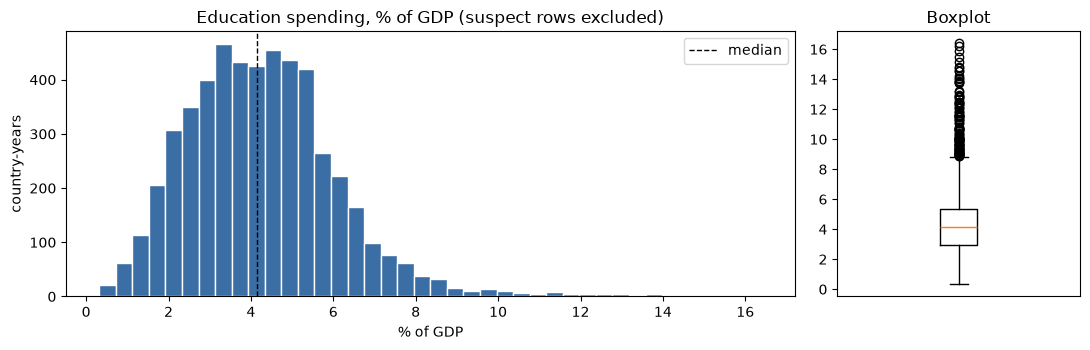

skewness: 1.19 | mean: 4.3 | median: 4.1


In [65]:
ok = spend_clean[~spend_clean["suspect"]]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [3, 1]})
ax[0].hist(ok["spend_pct_gdp"], bins=40, color="#3b6ea5", edgecolor="white")
ax[0].axvline(ok["spend_pct_gdp"].median(), color="black", ls="--", lw=1, label="median")
ax[0].set(title="Education spending, % of GDP (suspect rows excluded)", xlabel="% of GDP", ylabel="country-years")
ax[0].legend()
ax[1].boxplot(ok["spend_pct_gdp"], vert=True)
ax[1].set(title="Boxplot", xticks=[])
plt.tight_layout(); plt.show()
print("skewness:", round(ok["spend_pct_gdp"].skew(), 2), "| mean:", round(ok["spend_pct_gdp"].mean(), 1),
      "| median:", round(ok["spend_pct_gdp"].median(), 1))

**Shape (draft, check against your plot):** right-skewed (skewness about 1.2 once the suspect rows are out). Most country-years sit between about 3% and 5.5% of GDP, with the median near 4.1%. The long right tail is small Pacific states such as Kiribati at about 16%. Because of the tail, the mean (4.3) is a little above the median, so I will report the median and use rank-based correlation (Spearman) alongside Pearson.

## 5. Save

In [66]:
spend_clean.to_csv("C:/Users/kevin/capstone_kevina/data/cleaned/owid_spend_pct_gdp.csv", index=False)
print("saved", spend_clean.shape)
spend_clean.head()

saved (5164, 5)


,entity,code,year,spend_pct_gdp,suspect
0,Afghanistan,AFG,2010,3.47945,False
1,Afghanistan,AFG,2011,3.46201,False
2,Afghanistan,AFG,2012,2.60421,False
3,Afghanistan,AFG,2013,3.45446,False
4,Afghanistan,AFG,2014,3.69522,False
